In [71]:
import seaborn as sns
import dash
from dash import dcc, html
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [4]:
data=pd.read_csv("C:/Users/divya/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")
data


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
data.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [11]:
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

In [12]:
data.dtypes 

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Churn Counts:
 Churn
0    5174
1    1869
Name: count, dtype: int64
Percentage Distribution:
 Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


C:\Users\divya\AppData\Local\Temp\ipykernel_13580\3467145203.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Churn', palette='Set2')


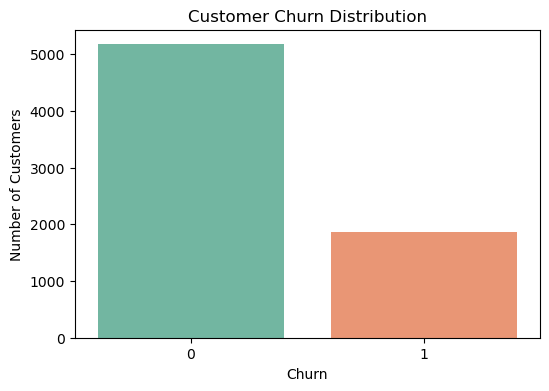

In [38]:
# Churn Column Distribution

# Count of churned vs not churned
churn_counts = data['Churn'].value_counts()
print("Churn Counts:\n", churn_counts)

# Percentage distribution
churn_percentage = data['Churn'].value_counts(normalize=True) * 100
print("Percentage Distribution:\n", churn_percentage)

# Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='Churn', palette='Set2')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()


In [20]:
corr_matrix = data.corr(numeric_only=True)
corr_matrix 


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102652
tenure,0.016567,1.000000,0.247900,0.825464
MonthlyCharges,0.220173,0.247900,1.000000,0.650864
TotalCharges,0.102652,0.825464,0.650864,1.000000


In [19]:
# Make a copy
data_corr = data.copy()

# Convert target variable 'Churn' to numeric (Yes=1, No=0)
data_corr['Churn'] = data_corr['Churn'].map({'Yes': 1, 'No': 0})

# Drop non-informative column
data_corr.drop('customerID', axis=1, inplace=True)

# Convert categorical variables to numeric for correlation
for col in data_corr.select_dtypes(include='object').columns:
    data_corr[col] = pd.factorize(data_corr[col])[0]

# Get correlations with Churn
correlations = data_corr.corr()['Churn'].sort_values(ascending=False)

# Display top 10 positively and negatively correlated features
print("Top positive correlations with Churn:\n", correlations.head(10))
print("\nTop negative correlations with Churn:\n", correlations.tail(10))


Top positive correlations with Churn:
 Churn              1.000000
MonthlyCharges     0.193356
SeniorCitizen      0.150889
Partner            0.150448
MultipleLines      0.036310
PhoneService       0.011942
gender            -0.008612
InternetService   -0.047291
OnlineBackup      -0.074205
Dependents        -0.164221
Name: Churn, dtype: float64

Top negative correlations with Churn:
 PaperlessBilling   -0.191825
TotalCharges       -0.199037
StreamingTV        -0.205742
StreamingMovies    -0.207256
PaymentMethod      -0.262818
DeviceProtection   -0.281465
TechSupport        -0.329852
OnlineSecurity     -0.332819
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64


In [19]:
# Make a copy
data_corr = data.copy()

# Convert target variable 'Churn' to numeric (Yes=1, No=0)
data_corr['Churn'] = data_corr['Churn'].map({'Yes': 1, 'No': 0})

# Drop non-informative column
data_corr.drop('customerID', axis=1, inplace=True)

# Convert categorical variables to numeric for correlation
for col in data_corr.select_dtypes(include='object').columns:
    data_corr[col] = pd.factorize(data_corr[col])[0]

# Get correlations with Churn
correlations = data_corr.corr()['Churn'].sort_values(ascending=False)

# Display top 10 positively and negatively correlated features
print("Top positive correlations with Churn:\n", correlations.head(10))
print("\nTop negative correlations with Churn:\n", correlations.tail(10))


Top positive correlations with Churn:
 Churn              1.000000
MonthlyCharges     0.193356
SeniorCitizen      0.150889
Partner            0.150448
MultipleLines      0.036310
PhoneService       0.011942
gender            -0.008612
InternetService   -0.047291
OnlineBackup      -0.074205
Dependents        -0.164221
Name: Churn, dtype: float64

Top negative correlations with Churn:
 PaperlessBilling   -0.191825
TotalCharges       -0.199037
StreamingTV        -0.205742
StreamingMovies    -0.207256
PaymentMethod      -0.262818
DeviceProtection   -0.281465
TechSupport        -0.329852
OnlineSecurity     -0.332819
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64


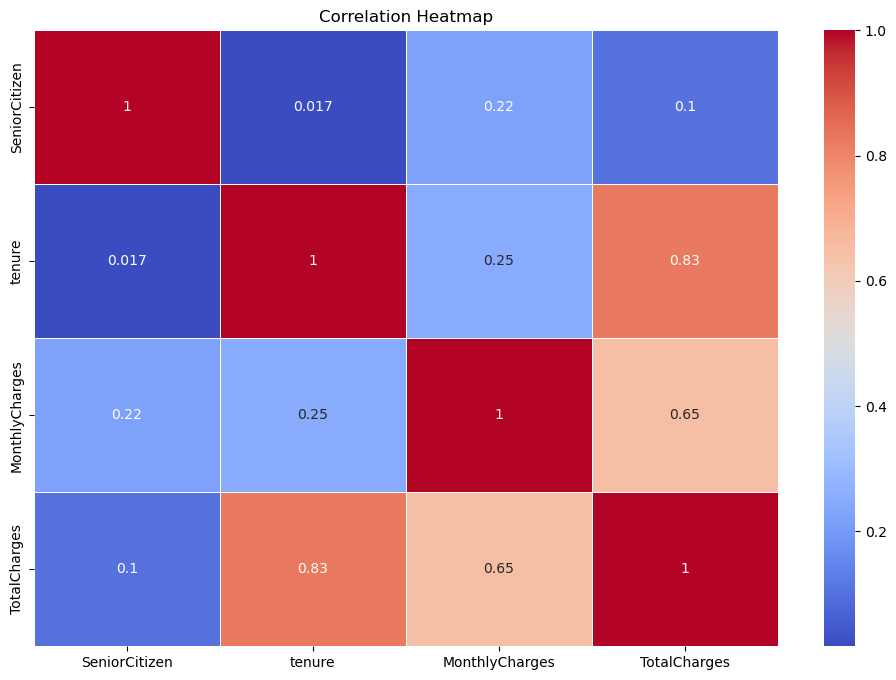

In [23]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


                                                           EXPLORATORY DATA ANALYSIS

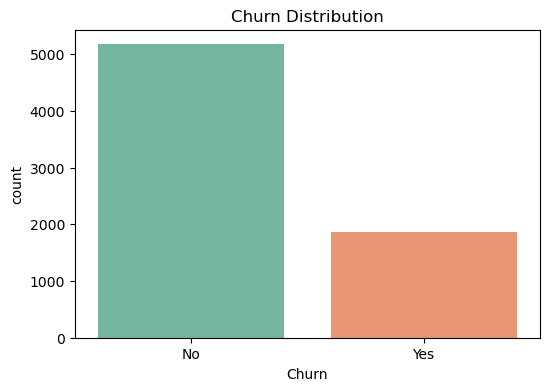

In [24]:
# Churn Distribution (Overall)
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title("Churn Distribution")
plt.show()

While the majority of customers are loyal, a significant 26% have churned — this is a red flag. Even though most customers are staying, losing nearly a quarter of your user base means there's something in the service model that isn’t working for a specific group.

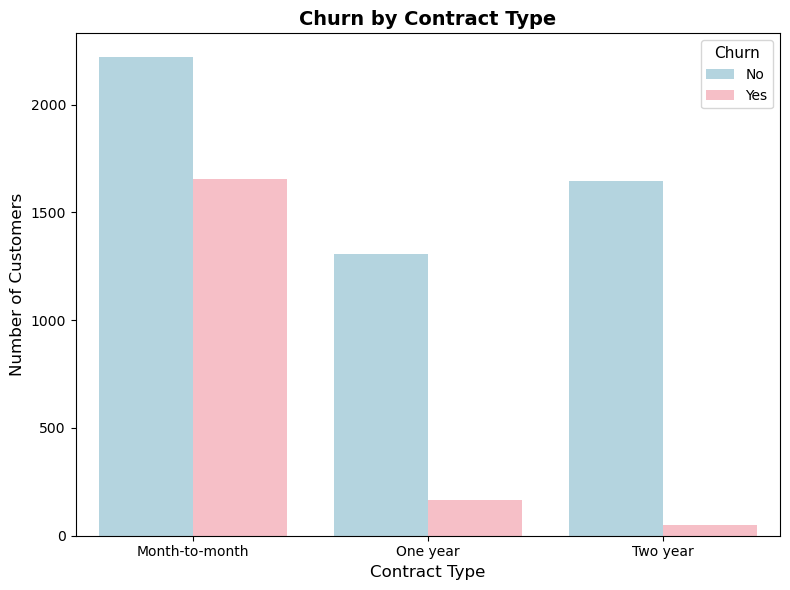

In [25]:
# Churn by Contract Type
plt.figure(figsize=(8, 6))
sns.countplot(
    data=data,
    x='Contract',
    hue='Churn',
    palette={'Yes': '#FFB6C1', 'No': '#ADD8E6'}  
)
plt.title("Churn by Contract Type", fontsize=14, fontweight='bold')
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.legend(title="Churn", title_fontsize=11, fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



Imagine this dataset as a storybook of customer behavior. The biggest red flag is waving right at the Month-to-month customers, who form the bulk of the churn army. These are flighty users — easy in, easy out. But on the flip side, long-term contracts create customer stickiness — once committed, they rarely leave. So, if churn reduction is your mission, the strategy is simple: convert month-to-month users into long-term subscribers through loyalty perks, bundle deals, or early renewal discounts

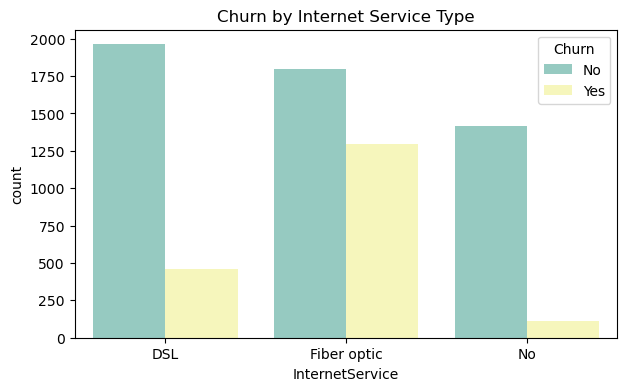

In [28]:
# Internet Service vs Churn
plt.figure(figsize=(7,4))
sns.countplot(data=data, x='InternetService', hue='Churn', palette='Set3')
plt.title("Churn by Internet Service Type")
plt.show()

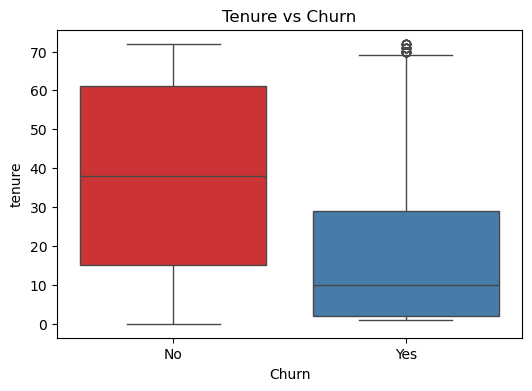

In [30]:
# Tenure vs Churn 
plt.figure(figsize=(6,4))
sns.boxplot(data=data, x='Churn', y='tenure', hue='Churn', palette='Set1', dodge=False, legend=False)
plt.title("Tenure vs Churn")
plt.show()

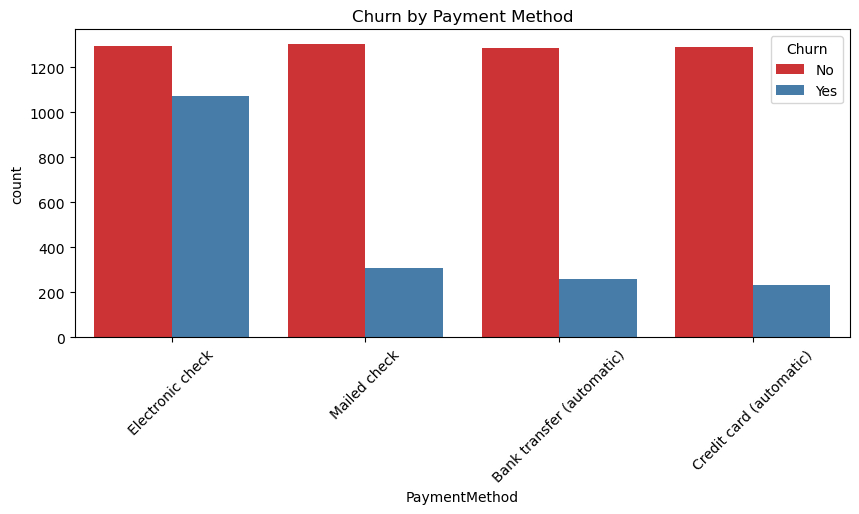

In [31]:
# Payment Method vs Churn
plt.figure(figsize=(10,4))
sns.countplot(data=data, x='PaymentMethod', hue='Churn', palette='Set1')
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()

                                         Feature Engineering (Adding features to make the ML models more accurate)

In [46]:
# Average Monthly Charge 
data['AvgMonthlyCharge'] = data['TotalCharges'] / data['tenure']
data['AvgMonthlyCharge'] = data['AvgMonthlyCharge'].replace([np.inf, -np.inf], 0)
data['AvgMonthlyCharge'] = data['AvgMonthlyCharge'].fillna(0)
print(data['AvgMonthlyCharge'].head())




0    29.850000
1    55.573529
2    54.075000
3    40.905556
4    75.825000
Name: AvgMonthlyCharge, dtype: float64


In [53]:
# Tenure Grouping (Customer Loyalty)
data['TenureGroup'] = pd.cut(data['tenure'],
                             bins=[0, 12, 24, 48, 72, data['tenure'].max() + 1],
                             labels=['0-1 yr', '1-2 yrs', '2-4 yrs', '4-6 yrs', '6+ yrs'])



In [52]:
# Total Services Subscribed
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

data['TotalServices'] = data[service_cols].apply(lambda row: sum(row == 'Yes'), axis=1)


In [54]:
# Has Fiber Optic Internet (Binary Feature)
data['HasFiberOptic'] = data['InternetService'].apply(lambda x: 1 if x == 'Fiber optic' else 0)


In [55]:
# Is Senior Citizen Binary
data['IsSenior'] = data['SeniorCitizen'].apply(lambda x: 'Senior' if x == 1 else 'Not Senior')


In [56]:
# Contract Type Simplicity
contract_map = {'Month-to-month': 1, 'One year': 12, 'Two year': 24}
data['ContractLength'] = data['Contract'].map(contract_map)


In [57]:
# AutoPay Enabled (from Payment Method)
data['AutoPay'] = data['PaymentMethod'].apply(lambda x: 1 if 'automatic' in x.lower() else 0)


In [58]:
# Has Tech Support or Not
data['HasTechSupport'] = data['TechSupport'].apply(lambda x: 1 if x == 'Yes' else 0)


In [60]:
# Streaming Activity
data['StreamingActivity'] = data.apply(lambda row: (
    1 if row['StreamingTV'] == 'Yes' or row['StreamingMovies'] == 'Yes' else 0), axis=1)


In [61]:
# Engagement Score 
def compute_engagement(row):
    score = 0
    if row['OnlineSecurity'] == 'Yes':
        score += 2
    if row['TechSupport'] == 'Yes':
        score += 2
    if row['StreamingTV'] == 'Yes':
        score += 1
    if row['StreamingMovies'] == 'Yes':
        score += 1
    if row['PhoneService'] == 'Yes':
        score += 1
    return score

data['EngagementScore'] = data.apply(compute_engagement, axis=1)


In [62]:
# Risk Score
def assign_risk(row):
    score = 0

    # 1. Contract Type
    if row['Contract'] == 'Month-to-month':
        score += 3
    elif row['Contract'] == 'One year':
        score += 1

    # 2. Payment Method
    if 'electronic check' in row['PaymentMethod'].lower():
        score += 2
    elif 'automatic' in row['PaymentMethod'].lower():
        score -= 1  # autopay = lower risk

    # 3. Tenure
    if row['tenure'] < 12:
        score += 3
    elif row['tenure'] < 24:
        score += 2
    elif row['tenure'] < 48:
        score += 1

    # 4. MonthlyCharges
    if row['MonthlyCharges'] > 80:
        score += 2

    # 5. TotalServices
    if row['TotalServices'] <= 2:
        score += 2
    elif row['TotalServices'] >= 5:
        score -= 1

    # 6. No Tech Support or Online Security
    if row['TechSupport'] != 'Yes':
        score += 1
    if row['OnlineSecurity'] != 'Yes':
        score += 1

    # 7. Senior Citizen
    if row['SeniorCitizen'] == 1:
        score += 1

    return score

# Apply to your data
data['RiskScore'] = data.apply(assign_risk, axis=1)


   RiskScore  Churn
0         12      0
1          3      0
2          7      1
3          1      0
4         12      1


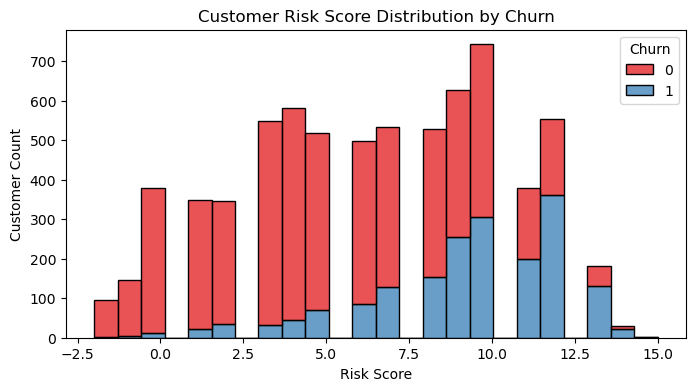

In [63]:
print(data[['RiskScore', 'Churn']].head())

# Visualize risk scores
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(data=data, x='RiskScore', hue='Churn', multiple='stack', palette='Set1')
plt.title('Customer Risk Score Distribution by Churn')
plt.xlabel('Risk Score')
plt.ylabel('Customer Count')
plt.show()


                                                            MACHINE LEARNING MODELS

Problem Statement -  Predict whether a customer will churn (Churn = Yes/No) based on:

1.Demographics:

 a. gender

 b. SeniorCitizen

 c.  Partner

 d.  Dependents


2.Behavioral features:

 a. tenure

 b. MonthlyCharges

 c. TotalCharges
 

3.Contract & Billing Info:

 a. Contract

 b. PaymentMethod

 c. PaperlessBilling
 

4.Service Usage:

 a. InternetService

 b. OnlineSecurity

 c. StreamingTV

In [101]:
# Pre-processing

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Encode categorical variables
data = pd.get_dummies(data, drop_first=True)

# Train-test split
X = data.drop("Churn", axis=1)
y = data["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [102]:
# MODEL 1: Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))


Random Forest Accuracy: 0.794889992902768


In [106]:
# MODEL 2: XG Boost
import xgboost as xgb
xgb_model = xgb.XGBClassifier( eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))


XGBoost Accuracy: 0.7927608232789212


In [104]:
# Gradient Boosting 

from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_preds))


Gradient Boosting Accuracy: 0.8090844570617459


In [123]:
# Save model, scaler, and column names
joblib.dump(gb, 'gradient_boost_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'trained_columns.pkl')

['trained_columns.pkl']

                                                     COMPARISON BETWEEN MODELS

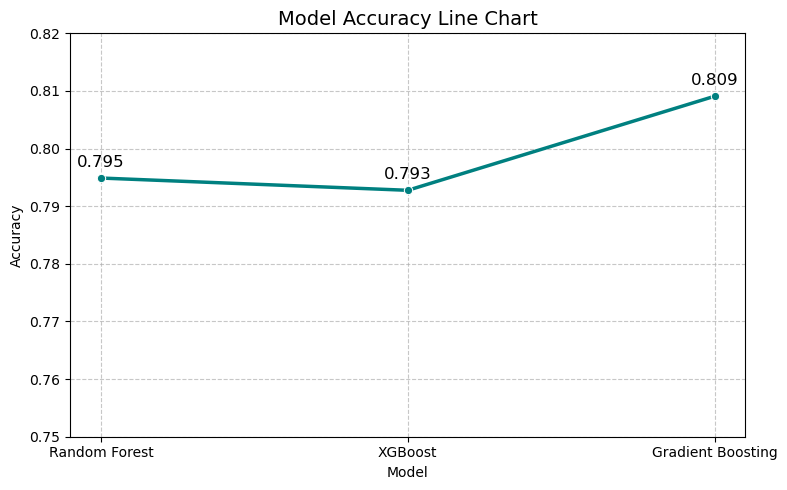

In [107]:

# Accuracy scores
model_scores = {
    "Random Forest": 0.794889992902768,
    "XGBoost": 0.7927608232789212,
    "Gradient Boosting": 0.8090844570617459
}

# Line chart
plt.figure(figsize=(8, 5))
sns.lineplot(x=list(model_scores.keys()), y=list(model_scores.values()), marker="o", linewidth=2.5, color="teal")
plt.ylim(0.75, 0.82)
plt.title("Model Accuracy Line Chart", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.grid(True, linestyle='--', alpha=0.7)

# Annotate accuracy on each point
for model, score in model_scores.items():
    plt.text(model, score + 0.002, f"{score:.3f}", ha='center', fontsize=12)

plt.tight_layout()
plt.show()


Line Chart Insights
The line chart clearly shows the accuracy progression across the three models tested:

1. Random Forest: 0.795

2. XGBoost: 0.793 (slightly lower than RF)

3. Gradient Boosting: 0.809 (highest)



In [110]:
import pandas as pd

# Create data
comparison_data = {
    "Feature": [
        "Accuracy", "Model Type", "Learning Style", "Speed", "Overfitting",
        "Interpretability", "Best For"
    ],
    "Random Forest": [
        "79.49%", "Bagging (Ensemble)", "Parallel Tree Growth", "Fast", "Low risk",
        "Moderate", "General use, quick tests"
    ],
    "XGBoost": [
        "79.28%", "Boosting (Ensemble)", "Sequential Tree Correction", "Moderate", "Moderate (needs tuning)",
        "Harder", "Large data, high accuracy"
    ],
    "Gradient Boosting": [
        "80.91%", "Boosting (Ensemble)", "Sequential Tree Correction", "Slower", "Lower risk (with tuning)",
        "Moderate", "Balanced prediction + generalization"
    ]
}

# Convert to DataFrame
data_comparison = pd.DataFrame(comparison_data)
data_comparison.set_index("Feature", inplace=True)

# Display as a clean table
from IPython.display import display
display(data_comparison)


,Random Forest,XGBoost,Gradient Boosting
Feature,,,
Accuracy,79.49%,79.28%,80.91%
Model Type,Bagging (Ensemble),Boosting (Ensemble),Boosting (Ensemble)
Learning Style,Parallel Tree Growth,Sequential Tree Correction,Sequential Tree Correction
Speed,Fast,Moderate,Slower
Overfitting,Low risk,Moderate (needs tuning),Lower risk (with tuning)
Interpretability,Moderate,Harder,Moderate
Best For,"General use, quick tests","Large data, high accuracy",Balanced prediction + generalization


Why Gradient Boosting is the Best

a.Superior Accuracy
Achieved the highest test accuracy (80.9%), making it the top performer for predicting churn effectively.

b.Smart Learning
Learns sequentially — each new tree improves upon the errors of the previous ones. This results in a powerful, focused learner.

c.Generalization
Tends to generalize better than Random Forest and XGBoost when properly tuned — perfect for real-world deployment.

d.Good Balance
Offers a great mix of performance, flexibility, and interpretability — ideal for business use cases like churn prediction.



                                                          APP FOR PREDICTION

In [111]:
import joblib
from sklearn.ensemble import GradientBoostingClassifier


gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

# Save model
joblib.dump(gb, 'gradient_boost_model.pkl')


['gradient_boost_model.pkl']

In [125]:
import dash
from dash import html, dcc
from dash.dependencies import Input, Output, State
import pandas as pd
import joblib

# Load model and preprocessing objects
model = joblib.load('gradient_boost_model.pkl')
scaler = joblib.load('scaler.pkl')
trained_columns = joblib.load('trained_columns.pkl')

# Input features (raw string format)
input_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                  'tenure', 'PhoneService', 'InternetService', 'Contract',
                  'MonthlyCharges', 'TotalCharges']

# Dash app setup
app = dash.Dash(__name__)
app.title = "Customer Churn Predictor"

app.layout = html.Div([
    html.H2("Customer Churn Prediction", style={'textAlign': 'center'}),
    *[
        html.Div([
            html.Label(f"{feature}:"),
            dcc.Input(id=feature, type='text', placeholder=f"Enter {feature}",
                      style={'marginBottom': '10px', 'width': '100%'})
        ])
        for feature in input_features
    ],
    html.Button("Predict", id="predict-btn", n_clicks=0, style={'marginTop': '20px'}),
    html.Div(id='prediction-output', style={'marginTop': '20px', 'fontWeight': 'bold'})
], style={'maxWidth': '600px', 'margin': 'auto'})

# Callback for prediction
@app.callback(
    Output('prediction-output', 'children'),
    Input('predict-btn', 'n_clicks'),
    [State(feature, 'value') for feature in input_features]
)
def predict_churn(n_clicks, *values):
    if n_clicks > 0:
        # Check for missing values
        if any(v is None or str(v).strip() == "" for v in values):
            return "⚠️ Please fill in all fields before predicting."

        try:
            # Prepare input
            input_dict = dict(zip(input_features, values))
            data = pd.DataFrame([input_dict])

            # Convert numeric fields
            data['SeniorCitizen'] = data['SeniorCitizen'].astype(int)
            data['tenure'] = data['tenure'].astype(int)
            data['MonthlyCharges'] = data['MonthlyCharges'].astype(float)
            data['TotalCharges'] = data['TotalCharges'].astype(float)

            # Encode categorical
            data_encoded = pd.get_dummies(data, drop_first=True)

            # Align with training columns
            data_encoded = data_encoded.reindex(columns=trained_columns, fill_value=0)

            # Scale
            data_scaled = scaler.transform(data_encoded)

            # Predict
            prediction = model.predict(data_scaled)[0]
            return f"Prediction: {'Churn' if prediction == 1 else 'No Churn'}"

        except Exception as e:
            return f"⚠️ Error: {e}"

    return ""

if __name__ == "__main__":
    app.run(debug=True)

